## **Consigna:** 
### Realizar un EDA básico del dataset seleccionado:

- estadística descriptiva
- tipos de variables
- identificación de duplicados, nulos, outliers
- incluir al menos 3 gráficos
- Guardarlo en un repositorio de acceso público o en una notebook de Google Colab. Lo importante es que el código esté ejecutado (que muestre la salida).





In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\tolot\\Documents\\UBA\\2026\\1B\\AdD\\Git\\CEIA_Analisis_de_datos\\Ejercicios\\Datasets\\Gaming and Mental Health.csv")


## Exploración inicial del dataset

Se realiza una inspección rápida del dataset para entender su estructura.  
Se muestran las primeras filas, las dimensiones, los nombres de las columnas y la información general de los datos

In [53]:
from IPython.display import display

print("=== Primeras filas del dataset ===")
display(df.head())

print("\n=== Dimensiones del dataset (filas, columnas) ===")
display(df.shape)

print("\n=== Columnas del dataset ===")
display(df.columns)

print("\n=== Información general ===")
df.info()

=== Primeras filas del dataset ===


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate



=== Dimensiones del dataset (filas, columnas) ===


(1000, 27)


=== Columnas del dataset ===


Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score',
       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',
       'years_gaming', 'gaming_addiction_risk_level'],
      dtype='str')


=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   str    
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   str    
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   str    
 5   primary_game                      1000 non-null   str    
 6   gaming_platform                   1000 non-null   str    
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   str    
 9   sleep_disruption_frequency        1000 non-null   str    
 10  academic_work_performance         1000 non-null   str    
 11  grades_gpa                        754 non-null    fl

## Estadística descriptiva

Se calculan estadísticas descriptivas para resumir el comportamiento de las variables del dataset.  
Se incluyen medidas como media, mediana, desviación estándar, valores mínimos y máximos, y percentiles.  
Esto permite tener una primera idea de la distribución y variabilidad de los datos.

In [54]:
from scipy.stats import entropy

print("=== Estadísticas descriptivas básicas ===")
display(df.describe())

print("\n=== Mediana de las variables numéricas ===")
display(df.median(numeric_only=True))

print("\n=== Moda de las variables ===")
display(df.mode().iloc[0])

print("\n=== Asimetría (Skewness) ===")
display(df.skew(numeric_only=True))

print("\n=== Curtosis ===")
display(df.kurtosis(numeric_only=True))



=== Estadísticas descriptivas básicas ===


,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000



=== Mediana de las variables numéricas ===


age                                 20.000
daily_gaming_hours                   6.000
sleep_hours                          5.700
grades_gpa                           2.530
work_productivity_score              5.000
withdrawal_symptoms                  0.000
loss_of_other_interests              0.000
continued_despite_problems           0.000
eye_strain                           0.000
back_neck_pain                       0.000
weight_change_kg                     1.100
exercise_hours_weekly                7.000
social_isolation_score               4.000
face_to_face_social_hours_weekly     8.000
monthly_game_spending_usd           66.405
years_gaming                         5.000
dtype: float64


=== Moda de las variables ===


record_id                              GD0001
age                                      19.0
gender                                   Male
daily_gaming_hours                        5.8
game_genre                               MOBA
primary_game                           Dota 2
gaming_platform                        Mobile
sleep_hours                               5.3
sleep_quality                            Fair
sleep_disruption_frequency              Often
academic_work_performance             Average
grades_gpa                                1.4
work_productivity_score                   9.0
mood_state                             Normal
mood_swing_frequency                Sometimes
withdrawal_symptoms                     False
loss_of_other_interests                 False
continued_despite_problems              False
eye_strain                              False
back_neck_pain                          False
weight_change_kg                          0.1
exercise_hours_weekly             


=== Asimetría (Skewness) ===


age                                 0.916952
daily_gaming_hours                  0.350818
sleep_hours                         0.228904
grades_gpa                         -0.049009
work_productivity_score             0.049386
withdrawal_symptoms                 0.937739
loss_of_other_interests             0.753267
continued_despite_problems          2.090164
eye_strain                          0.012018
back_neck_pain                      0.639164
weight_change_kg                    1.651558
exercise_hours_weekly              -0.163397
social_isolation_score              0.523447
face_to_face_social_hours_weekly   -0.157971
monthly_game_spending_usd           1.842069
years_gaming                        0.963213
dtype: float64


=== Curtosis ===


age                                 0.890129
daily_gaming_hours                 -0.181242
sleep_hours                        -0.448717
grades_gpa                         -1.256997
work_productivity_score            -1.250953
withdrawal_symptoms                -1.122896
loss_of_other_interests            -1.435464
continued_despite_problems          2.373530
eye_strain                         -2.003867
back_neck_pain                     -1.594663
weight_change_kg                    3.400097
exercise_hours_weekly              -0.188263
social_isolation_score             -0.194213
face_to_face_social_hours_weekly   -0.598928
monthly_game_spending_usd           2.641796
years_gaming                        0.803367
dtype: float64

## Tipos de variables

En este bloque se identifican los tipos de datos presentes en el dataset.  
Esto permite distinguir entre variables numéricas, categóricas, booleanas o de fecha, lo cual es importante para decidir qué análisis y visualizaciones aplicar.

In [55]:
print("=== Tipos de datos de cada variable ===")
display(df.dtypes)

print("\n=== Conteo de tipos de variables ===")
display(df.dtypes.value_counts())

print("\n=== Variables numéricas ===")
display(df.select_dtypes(include=["number"]).columns)

print("\n=== Variables categóricas ===")
display(df.select_dtypes(include=["object", "category", "string"]).columns)

print("\n=== Variables booleanas ===")
display(df.select_dtypes(include=["bool"]).columns)

print("\n=== Variables de fecha ===")
display(df.select_dtypes(include=["datetime"]).columns)

=== Tipos de datos de cada variable ===


record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality                           str
sleep_disruption_frequency              str
academic_work_performance               str
grades_gpa                          float64
work_productivity_score             float64
mood_state                              str
mood_swing_frequency                    str
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exercise_hours_weekly               float64
social_isolation_score          


=== Conteo de tipos de variables ===


str        11
float64     8
bool        5
int64       3
Name: count, dtype: int64


=== Variables numéricas ===


...

Index(['record_id', 'gender', 'game_genre', 'primary_game', 'gaming_platform',
       'sleep_quality', 'sleep_disruption_frequency',
       'academic_work_performance', 'mood_state', 'mood_swing_frequency',
       'gaming_addiction_risk_level'],
      dtype='str')


=== Variables booleanas ===


Index(['withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain'],
      dtype='str')


=== Variables de fecha ===


Index([], dtype='str')

## Calidad de datos: duplicados, valores nulos y outliers

Se analizan posibles problemas en la calidad del dataset.  
Se identifican registros duplicados, valores faltantes en cada variable y posibles outliers en variables numéricas utilizando el método del rango intercuartílico (IQR).  
Esto permite detectar inconsistencias que podrían afectar el análisis posterior.

In [56]:
print("=== Registros duplicados ===")
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)

print("\n=== Valores nulos por variable ===")
nulos = df.isnull().sum()
display(nulos)

print("\n=== Porcentaje de valores nulos ===")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
display(porcentaje_nulos)

print("\n=== Outliers en variables numéricas (método IQR) ===")

df_num = df.select_dtypes(include="number")

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))

display(outliers.sum())

=== Registros duplicados ===
Cantidad de filas duplicadas: 0

=== Valores nulos por variable ===


record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0



=== Porcentaje de valores nulos ===


record_id                            0.0
age                                  0.0
gender                               0.0
daily_gaming_hours                   0.0
game_genre                           0.0
primary_game                         0.0
gaming_platform                      0.0
sleep_hours                          0.0
sleep_quality                        0.0
sleep_disruption_frequency           0.0
academic_work_performance            0.0
grades_gpa                          24.6
work_productivity_score             32.6
mood_state                           0.0
mood_swing_frequency                 0.0
withdrawal_symptoms                  0.0
loss_of_other_interests              0.0
continued_despite_problems           0.0
eye_strain                           0.0
back_neck_pain                       0.0
weight_change_kg                     0.0
exercise_hours_weekly                0.0
social_isolation_score               0.0
face_to_face_social_hours_weekly     0.0
monthly_game_spe


=== Outliers en variables numéricas (método IQR) ===


age                                  50
daily_gaming_hours                    6
sleep_hours                           0
grades_gpa                            0
work_productivity_score               0
weight_change_kg                     40
exercise_hours_weekly                 2
social_isolation_score               10
face_to_face_social_hours_weekly      0
monthly_game_spending_usd           107
years_gaming                         20
dtype: int64

## Visualización de datos

Se generan tres gráficos para explorar visualmente el comportamiento del dataset:

- **Histograma:** permite observar la distribución de una variable numérica.
- **Boxplot:** ayuda a identificar la dispersión de los datos y posibles outliers.
- **Matriz de correlación (heatmap):** muestra la relación entre variables numéricas del dataset.

Estas visualizaciones complementan la estadística descriptiva y facilitan la detección de patrones o anomalías en los datos.

C:\Users\tolot\AppData\Local\Temp\ipykernel_30220\4014344432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gaming_addiction_risk_level', palette='viridis',


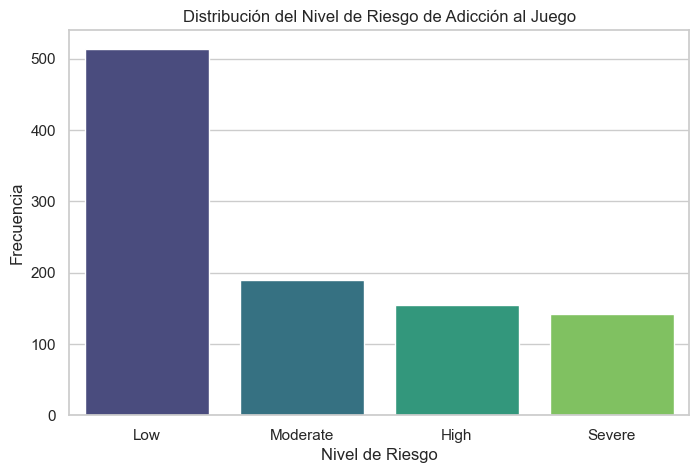

In [57]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gaming_addiction_risk_level', palette='viridis', 
              order=['Low', 'Moderate', 'High', 'Severe'])
plt.title('Distribución del Nivel de Riesgo de Adicción al Juego')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Frecuencia')
plt.show()

C:\Users\tolot\AppData\Local\Temp\ipykernel_30220\3943551201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sleep_quality', y='daily_gaming_hours',


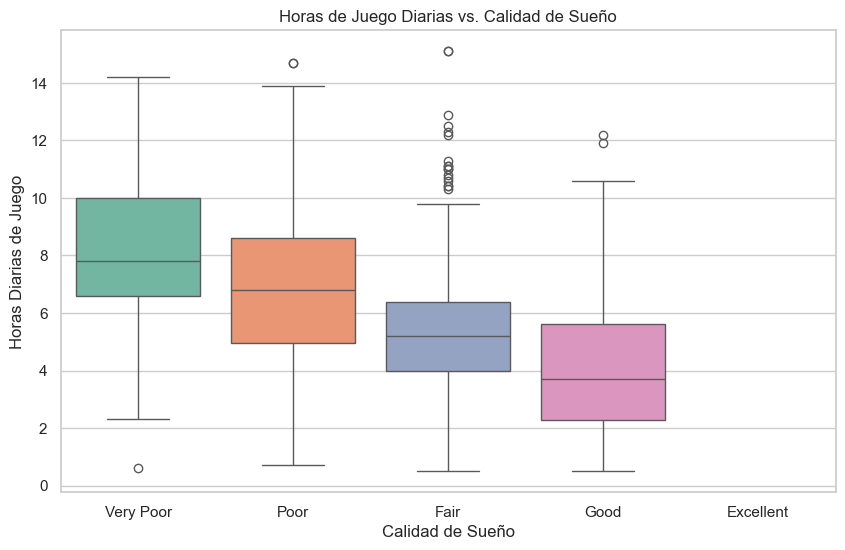

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sleep_quality', y='daily_gaming_hours', 
            palette='Set2', order=['Very Poor', 'Poor', 'Fair', 'Good', 'Excellent'])
plt.title('Horas de Juego Diarias vs. Calidad de Sueño')
plt.xlabel('Calidad de Sueño')
plt.ylabel('Horas Diarias de Juego')
plt.show()

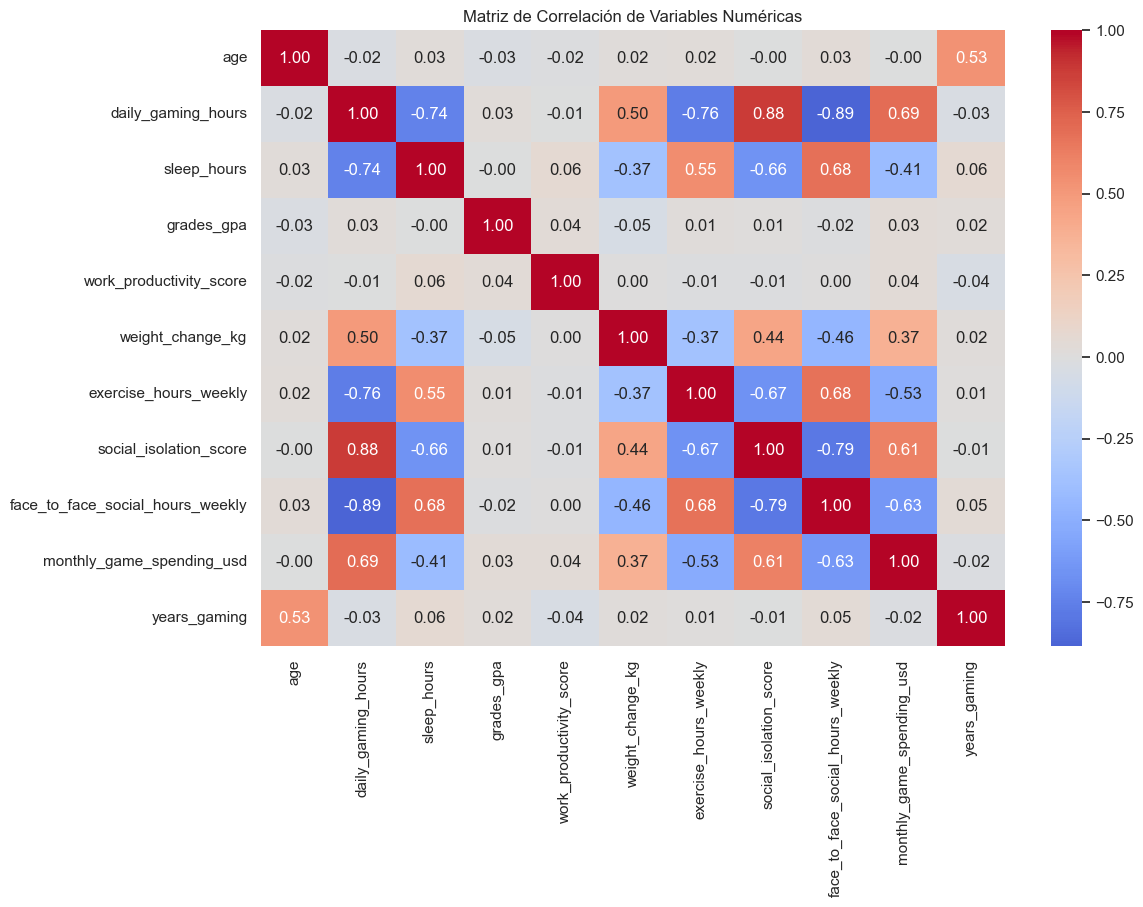

In [59]:
plt.figure(figsize=(12, 8))
# Seleccionamos solo las numéricas para la matriz
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Informe de Análisis Exploratorio de Datos (EDA)

## 1. Descripción del Dataset y Tipos de Variables
El dataset contiene información sobre el comportamiento de juego y su impacto en la salud mental de **1000 usuarios**. Presenta la siguiente distribución de variables:

* **Numéricas (11):** Variables como `age`, `daily_gaming_hours`, `sleep_hours` y `monthly_game_spending_usd`.
* **Categóricas (11):** Clasificaciones como `gender`, `game_genre` y niveles ordinales como `gaming_addiction_risk_level`.
* **Booleanas (5):** Flags de síntomas físicos y psicológicos (ej. `withdrawal_symptoms`, `eye_strain`).

## 2. Calidad de los Datos (Limpieza)
* **Duplicados:** Se confirmó la ausencia de registros duplicados ($0\%$).
* **Valores Nulos:** Se detectó una deficiencia de datos en variables de rendimiento:
    * `grades_gpa`: **24.6%** de valores faltantes.
    * `work_productivity_score`: **32.6%** de valores faltantes.
* **Outliers:** Mediante el método de **Rango Intercuartílico (IQR)**, se identificaron valores atípicos significativos en `monthly_game_spending_usd` (107 casos) y `weight_change_kg`. 

## 3. Análisis Estadístico y Distribuciones
El análisis de **Skewness (Asimetría)** y **Curtosis** revela distribuciones no normales en variables críticas:
* **Asimetría Positiva ($>1$):** Variables como el gasto mensual y el cambio de peso muestran una "cola" hacia la derecha. Esto indica que un pequeño grupo de usuarios tiene consumos y cambios físicos muy por encima de la media.
* **Curtosis:** Los valores elevados confirman la presencia de valores extremos (outliers) que hacen que la distribución sea más "puntiaguda" que una normal.

## 4. Interpretación de Resultados Visuales

### A. Frecuencia de Riesgo de Adicción
El gráfico de barras muestra un cierto desbalance. La mayoría de los individuos se encuentran en riesgo "Low", pudiendo interpretarse como un "sesgo" hacia una población saludable.


### B. Relación Juego vs. Sueño (Análisis Bivariado)
A través de los diagramas de caja (boxplots), se observa que a medida que la calidad de sueño es reportada como "Poor" o "Very Poor", la mediana de horas de juego diarias tiende a ser más alta. Los outliers en categorías de buen sueño indican casos excepcionales que juegan mucho sin percibir (aún) impacto en su descanso.



### C. Mapa de Calor de Correlaciones
El heatmap permite identificar que las horas de juego diarias tienen la correlación más fuerte con el puntaje de **aislamiento social**. Estadísticamente, esto sugiere una relación de dependencia lineal entre el tiempo frente a la pantalla y la reducción de interacción física.



---